In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load data
df_train = pd.read_csv('training.csv')
df_test = pd.read_csv('testing.csv')

# Define target variables and features
targets = ['TEY', 'NOX']
features = ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'CDP']

# --- 1. Feature Selection: Select top 4 features for each target based on absolute correlation ---
correlations = df_train.corr()
top_features = {}

for target in targets:
    top_features[target] = correlations[target][features].abs().nlargest(4).index.tolist()

print("Top 4 features for each target:")
for feature in top_features.items():
    print(feature)

Top 4 features for each target:
('TEY', ['CDP', 'GTEP', 'TIT', 'TAT'])
('NOX', ['AT', 'TIT', 'GTEP', 'AP'])


In [3]:
# --- 2. Train Multiple Regression with Top 4 Features ---
models = {}
results = {}

for target in targets:
    # Use selected top 4 features
    selected_features = top_features[target]

    # Prepare data
    X_train, y_train = df_train[selected_features], df_train[target]
    X_test, y_test = df_test[selected_features], df_test[target]

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)
    models[target] = model

    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    results[target] = {
        'features': selected_features,
        'r2_train': r2_train,
        'r2_test': r2_test,
        'rmse_train': rmse_train,
        'rmse_test': rmse_test
    }

print("\nMultiple Regression Results:")
for result in results.items():
    print(result)


Multiple Regression Results:
('TEY', {'features': ['CDP', 'GTEP', 'TIT', 'TAT'], 'r2_train': 0.9787767951101303, 'r2_test': 0.9781544613446442, 'rmse_train': 2.275567224065215, 'rmse_test': 2.307370357746562})
('NOX', {'features': ['AT', 'TIT', 'GTEP', 'AP'], 'r2_train': 0.3526624063408079, 'r2_test': 0.3448977770098087, 'rmse_train': 9.42913104581565, 'rmse_test': 9.317263925845477})


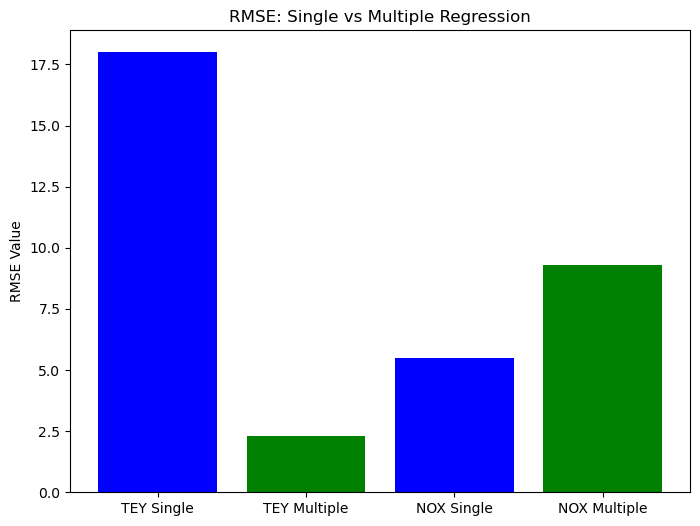

In [4]:
# --- 3. Compare RMSE (Single Feature vs Multiple Feature) ---
single_feature_rmse = {
    'TEY': 18.0,  # Replace with RMSE from previous single-feature models
    'NOX': 5.5     # Replace with RMSE from previous single-feature models
}

x_labels = ['TEY Single', 'TEY Multiple', 'NOX Single', 'NOX Multiple']
y_values = [single_feature_rmse['TEY'], results['TEY']['rmse_test'],
            single_feature_rmse['NOX'], results['NOX']['rmse_test']]

plt.figure(figsize=(8, 6))
plt.bar(x_labels, y_values, color=['blue', 'green', 'blue', 'green'])
plt.title("RMSE: Single vs Multiple Regression")
plt.ylabel("RMSE Value")
plt.show()

In [5]:
# --- 4. Train Multiple Regression using ALL Features ---
all_features = features  # All available features

models_all = {}
results_all = {}

for target in targets:
    X_train, y_train = df_train[all_features], df_train[target]
    X_test, y_test = df_test[all_features], df_test[target]

    model = LinearRegression()
    model.fit(X_train, y_train)
    models_all[target] = model

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    results_all[target] = {
        'features': all_features,
        'r2_train': r2_train,
        'r2_test': r2_test,
        'rmse_train': rmse_train,
        'rmse_test': rmse_test
    }

print("\nAll Features Regression Results:")
for result in results_all.items():
    print(result)


All Features Regression Results:
('TEY', {'features': ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'CDP'], 'r2_train': 0.996087802574749, 'r2_test': 0.9960561256804281, 'rmse_train': 0.9770000093673402, 'rmse_test': 0.980386818680863})
('NOX', {'features': ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'CDP'], 'r2_train': 0.4961666579056303, 'r2_test': 0.4699747204984249, 'rmse_train': 8.318589799953175, 'rmse_test': 8.380735860495335})


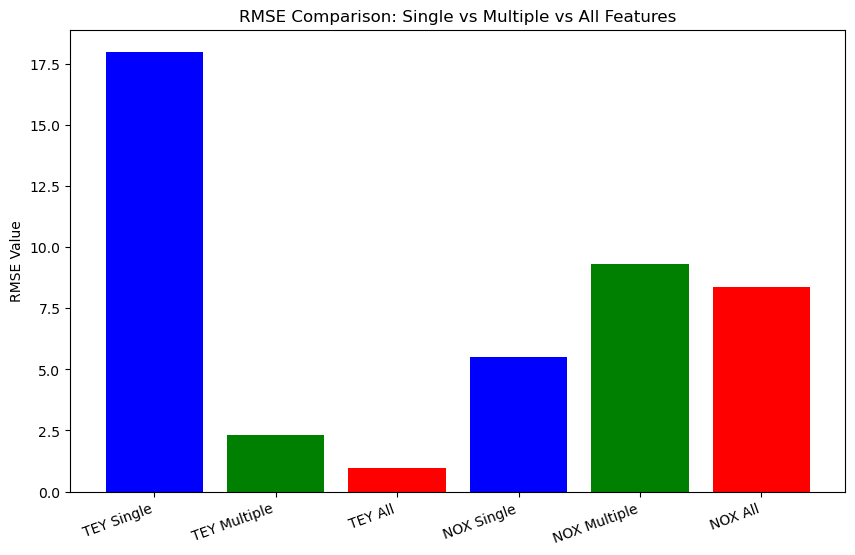

In [6]:
# --- 5. Compare RMSE (Single vs Multiple vs All-Features) ---
x_labels = ['TEY Single', 'TEY Multiple', 'TEY All',
            'NOX Single', 'NOX Multiple', 'NOX All']
y_values = [single_feature_rmse['TEY'], results['TEY']['rmse_test'], results_all['TEY']['rmse_test'],
            single_feature_rmse['NOX'], results['NOX']['rmse_test'], results_all['NOX']['rmse_test']]

plt.figure(figsize=(10, 6))
plt.bar(x_labels, y_values, color=['blue', 'green', 'red', 'blue', 'green', 'red'])
plt.title("RMSE Comparison: Single vs Multiple vs All Features")
plt.ylabel("RMSE Value")
plt.xticks(rotation=20, ha='right')
plt.show()

Does employing more features to train the ML model improve performance? (Hint: Create a barchart of RMSE of single and multiple regression to prove your point)

- Strong correlation with the target data does not necessarily mean better performance, snce each feature can constrain others in getting to the actual result.
- In TEY case, the parameter is high independent. Incorporating more parameters based on the high correlation bias the decision, which then make the prediction far off the actual value in the testing dataset.
- In NOX case, the high correlated parameters help the prediction on NOx better, since NOx are dependent on the its primary features. Incorporating in all parameters found make the decision less accurate since one parameter can constrain the others, because the parameters are assumed to have a direct relationship to the target feature.